# 📊 People Analytics — Auditoría de Reclutamiento
### Análisis end-to-end del proceso de selección
**Herramientas:** Python · Pandas · Matplotlib · Seaborn  
**Autora:** Eliana

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [28]:
# Cargue todos los archivos
candidates   = pd.read_csv('../data/candidates.csv')
pipeline     = pd.read_csv('../data/pipeline.csv')
job_req      = pd.read_csv('../data/job_req.csv')
offers       = pd.read_csv('../data/offers.csv')
onboarding   = pd.read_csv('../data/onboarding.csv')
performance  = pd.read_csv('../data/performance_fact.csv')
cost_source  = pd.read_csv('../data/cost_by_source.csv')

print("✅ Todos los archivos cargados correctamente")
print(f"👥 Candidatos: {len(candidates):,}")
print(f"🔄 Movimientos en pipeline: {len(pipeline):,}")
print(f"📋 Posiciones abiertas: {len(job_req):,}")
print(f"💼 Ofertas realizadas: {len(offers):,}")

✅ Todos los archivos cargados correctamente
👥 Candidatos: 11,637
🔄 Movimientos en pipeline: 25,624
📋 Posiciones abiertas: 900
💼 Ofertas realizadas: 250


In [29]:
# Cómo son los datos de cada archivo
for nombre, df in {
    "candidates": candidates,
    "pipeline": pipeline,
    "job_req": job_req,
    "offers": offers,
    "onboarding": onboarding,
    "performance": performance,
    "cost_source": cost_source
}.items():
    print(f"\n{'='*45}")
    print(f"📁 {nombre.upper()}")
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
    print(f"Columnas: {list(df.columns)}")


📁 CANDIDATES
Filas: 11,637 | Columnas: 9
Columnas: ['id', 'job_id', 'source', 'experience_years', 'education', 'gender', 'applied_date', 'city', 'expected_salary']

📁 PIPELINE
Filas: 25,624 | Columnas: 4
Columnas: ['candidate_id', 'stage', 'stage_date', 'recruiter']

📁 JOB_REQ
Filas: 900 | Columnas: 9
Columnas: ['id', 'area', 'role', 'seniority', 'site', 'recruiter', 'req_date', 'salary_offer', 'target_hires']

📁 OFFERS
Filas: 250 | Columnas: 8
Columnas: ['candidate_id', 'job_id', 'expected_salary', 'source', 'offer_date', 'salary_offer', 'pay_gap', 'decision']

📁 ONBOARDING
Filas: 181 | Columnas: 6
Columnas: ['employee_id', 'candidate_id', 'job_id', 'start_date', 'time_to_fill_days', 'time_to_hire_days']

📁 PERFORMANCE
Filas: 181 | Columnas: 5
Columnas: ['employee_id', 'candidate_id', 'job_id', 'retained_90d', 'rating_6m']

📁 COST_SOURCE
Filas: 138 | Columnas: 3
Columnas: ['month', 'source', 'cost_ars']


In [30]:
print("🔍 VERIFICACIÓN DE DATOS FALTANTES\n")
for nombre, df in {
    "candidates": candidates,
    "pipeline": pipeline,
    "job_req": job_req,
    "offers": offers,
    "onboarding": onboarding,
    "performance": performance,
    "cost_source": cost_source
}.items():
    nulos = df.isnull().sum()
    total_nulos = nulos.sum()
    if total_nulos > 0:
        print(f"⚠️  {nombre.upper()} — {total_nulos} valores nulos:")
        print(nulos[nulos > 0])
    else:
        print(f"✅ {nombre.upper()} — sin valores nulos")
    print()

🔍 VERIFICACIÓN DE DATOS FALTANTES

✅ CANDIDATES — sin valores nulos

✅ PIPELINE — sin valores nulos

✅ JOB_REQ — sin valores nulos

✅ OFFERS — sin valores nulos

✅ ONBOARDING — sin valores nulos

✅ PERFORMANCE — sin valores nulos

✅ COST_SOURCE — sin valores nulos



## 🔍 1. Funnel de Conversión
¿Dónde se pierden los candidatos en el proceso de selección?

Se analizaron cuántos candidatos pasan por cada etapa del pipeline
para identificar los cuellos de botella.

In [31]:
# Orden lógico de las etapas del proceso
orden_etapas = [
    'applied', 'screening', 'interview_tech',
    'interview_mgr', 'offer', 'decision'
]

# Conté candidatos únicos por etapa
funnel = pipeline[pipeline['stage'].isin(orden_etapas)]\
         .groupby('stage')['candidate_id']\
         .nunique()\
         .reindex(orden_etapas)

print("📊 Candidatos por etapa:")
print(funnel)
print(f"\nTasa de conversión total: {funnel['decision']/funnel['applied']*100:.1f}%")

📊 Candidatos por etapa:
stage
applied           11637
screening          8507
interview_tech     3951
interview_mgr      1239
offer               250
decision             40
Name: candidate_id, dtype: int64

Tasa de conversión total: 0.3%


C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\595448140.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\595448140.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/funnel_conversion.png', dpi=150, bbox_inches='tight')
C:\Users\sanch\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


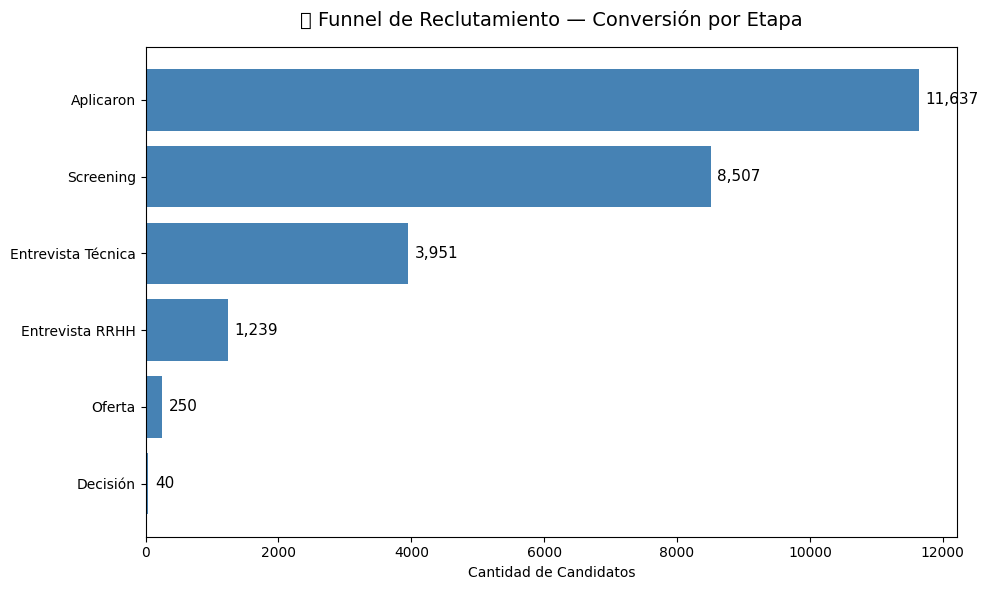

✅ Gráfico guardado en outputs/


In [32]:
# Etiqueta para gráfico
etiquetas = [
    'Aplicaron', 'Screening', 'Entrevista Técnica',
    'Entrevista RRHH', 'Oferta', 'Decisión'
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(etiquetas, funnel.values, color='steelblue')

# Se agregaron los números en cada barra
for bar, valor in zip(bars, funnel.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{valor:,}', va='center', fontsize=11)

ax.set_xlabel('Cantidad de Candidatos')
ax.set_title('📊 Funnel de Reclutamiento — Conversión por Etapa', fontsize=14, pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/funnel_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en outputs/")

## 📣 2. Análisis por Fuente de Reclutamiento
¿Qué canal trae más candidatos y cuál es más efectivo?

Analicé el volumen de candidatos por fuente para identificar
qué canales generan mayor cantidad y cuáles tienen mejor conversión.

In [33]:
# Conté candidatos por fuente
por_fuente = candidates.groupby('source')['id'].count().sort_values(ascending=False)

print("📣 Candidatos por fuente:")
print(por_fuente)
print(f"\nTotal fuentes: {len(por_fuente)}")

📣 Candidatos por fuente:
source
LinkedIn         4826
Referido         2154
Portal Empleo    1846
Agencia          1396
Orgánico          959
Universidades     456
Name: id, dtype: int64

Total fuentes: 6


C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\3987235222.py:13: UserWarning: Glyph 128227 (\N{CHEERING MEGAPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\3987235222.py:14: UserWarning: Glyph 128227 (\N{CHEERING MEGAPHONE}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/candidatos_por_fuente.png', dpi=150, bbox_inches='tight')
C:\Users\sanch\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128227 (\N{CHEERING MEGAPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


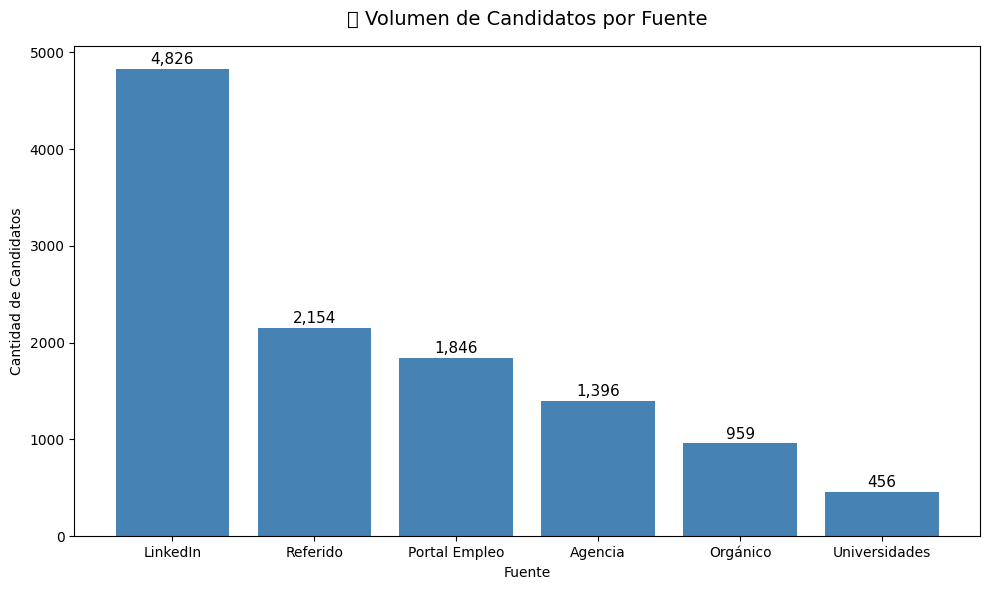

✅ Gráfico guardado en outputs/


In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(por_fuente.index, por_fuente.values, color='steelblue')

# Números arriba de cada barra
for bar, valor in zip(bars, por_fuente.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{valor:,}', ha='center', fontsize=11)

ax.set_xlabel('Fuente')
ax.set_ylabel('Cantidad de Candidatos')
ax.set_title('📣 Volumen de Candidatos por Fuente', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../outputs/candidatos_por_fuente.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en outputs/")

## ⏱️ 3. Time to Hire y Time to Fill
¿Cuánto tarda el proceso de selección?

Analicé el tiempo promedio que lleva cubrir una posición
desde que se abre el requerimiento hasta que el candidato ingresa.

In [35]:
# Estadísticas de tiempo
print("⏱️ TIEMPO DEL PROCESO DE SELECCIÓN\n")
print(f"Time to Hire promedio:  {onboarding['time_to_hire_days'].mean():.0f} días")
print(f"Time to Fill promedio:  {onboarding['time_to_fill_days'].mean():.0f} días")
print(f"\nTime to Hire mínimo:  {onboarding['time_to_hire_days'].min()} días")
print(f"Time to Hire máximo:  {onboarding['time_to_hire_days'].max()} días")
print(f"\nTime to Fill mínimo:  {onboarding['time_to_fill_days'].min()} días")
print(f"Time to Fill máximo:  {onboarding['time_to_fill_days'].max()} días")

⏱️ TIEMPO DEL PROCESO DE SELECCIÓN

Time to Hire promedio:  16 días
Time to Fill promedio:  77 días

Time to Hire mínimo:  6 días
Time to Hire máximo:  29 días

Time to Fill mínimo:  33 días
Time to Fill máximo:  111 días


C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\3044397979.py:20: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\3044397979.py:20: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\3044397979.py:21: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/tiempos_proceso.png', dpi=150, bbox_inches='tight')
C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\3044397979.py:21: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/tiempos_proceso.png', dpi=150, bbox_inches='tight')
C:\Users\sanch\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) 

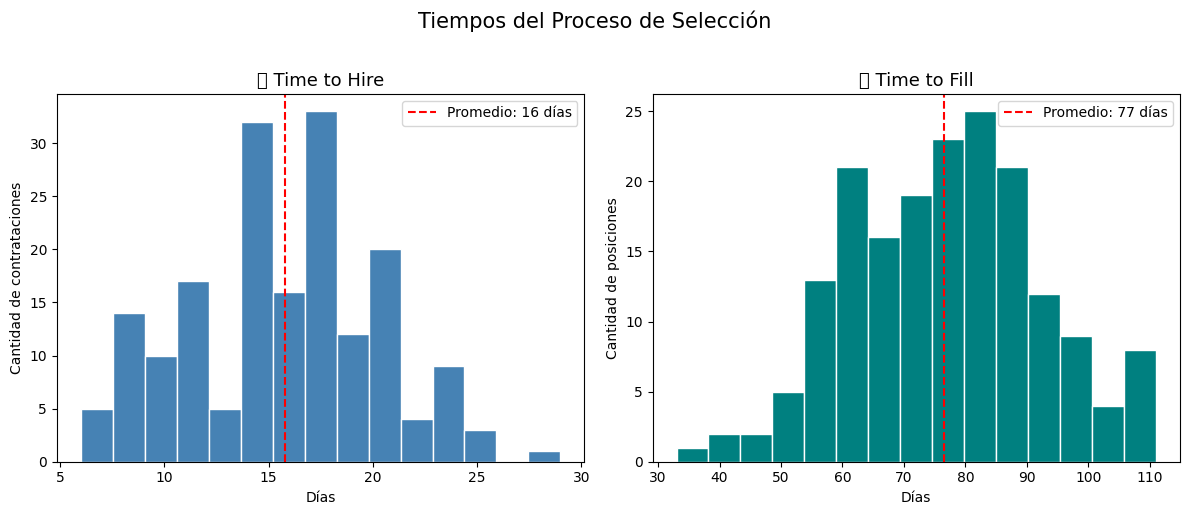

✅ Gráfico guardado en outputs/


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Time to Hire
axes[0].hist(onboarding['time_to_hire_days'], bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(onboarding['time_to_hire_days'].mean(), color='red', linestyle='--', label=f'Promedio: {onboarding["time_to_hire_days"].mean():.0f} días')
axes[0].set_title('⏱️ Time to Hire', fontsize=13)
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Cantidad de contrataciones')
axes[0].legend()

# Time to Fill
axes[1].hist(onboarding['time_to_fill_days'], bins=15, color='teal', edgecolor='white')
axes[1].axvline(onboarding['time_to_fill_days'].mean(), color='red', linestyle='--', label=f'Promedio: {onboarding["time_to_fill_days"].mean():.0f} días')
axes[1].set_title('📅 Time to Fill', fontsize=13)
axes[1].set_xlabel('Días')
axes[1].set_ylabel('Cantidad de posiciones')
axes[1].legend()

plt.suptitle('Tiempos del Proceso de Selección', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/tiempos_proceso.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en outputs/")

## ⚖️ 4. Análisis de Brecha Salarial (Pay Gap)
¿Existe diferencia entre el salario esperado por género?

Analicé si hay una brecha entre lo que esperan ganar
los candidatos según su género, y cómo se compara con las ofertas realizadas.

In [37]:
# Salario esperado promedio por género
pay_gap = candidates.groupby('gender')['expected_salary'].mean().sort_values()

print("⚖️ SALARIO ESPERADO PROMEDIO POR GÉNERO\n")
for genero, salario in pay_gap.items():
    print(f"{genero}: ${salario:,.0f}")

# Diferencia
diferencia = pay_gap.max() - pay_gap.min()
pct = (diferencia / pay_gap.max()) * 100
print(f"\nBrecha salarial: ${diferencia:,.0f} ({pct:.1f}%)")

⚖️ SALARIO ESPERADO PROMEDIO POR GÉNERO

X: $2,864,249
F: $2,914,154
M: $2,920,032

Brecha salarial: $55,783 (1.9%)


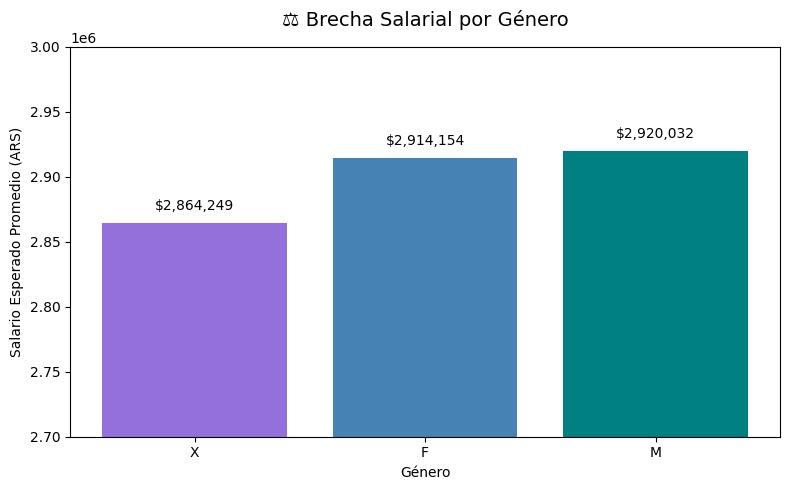

✅ Gráfico guardado en outputs/


In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

colores = {'F': 'steelblue', 'M': 'teal', 'X': 'mediumpurple'}
bars = ax.bar(pay_gap.index, pay_gap.values, 
              color=[colores[g] for g in pay_gap.index])

# Números arriba de cada barra
for bar, valor in zip(bars, pay_gap.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'${valor:,.0f}', ha='center', fontsize=10)

ax.set_xlabel('Género')
ax.set_ylabel('Salario Esperado Promedio (ARS)')
ax.set_title('⚖️ Brecha Salarial por Género', fontsize=14, pad=15)
ax.set_ylim(2_700_000, 3_000_000)
plt.tight_layout()
plt.savefig('../outputs/pay_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en outputs/")

## 🏆 5. Calidad de Contratación por Fuente
¿Qué fuente trae los mejores empleados?

Analicé la retención a 90 días y el rating de performance a 6 meses
de los empleados contratados, agrupado por fuente de origen.

In [40]:
# Uni performance con candidates para traer la fuente
df_calidad = performance.merge(candidates[['id', 'source']], 
                                left_on='candidate_id', 
                                right_on='id', 
                                how='left')

# Calidad por fuente
calidad = df_calidad.groupby('source').agg(
    retencion_90d=('retained_90d', 'mean'),
    rating_6m=('rating_6m', 'mean'),
    contratados=('candidate_id', 'count')
).round(2).sort_values('rating_6m', ascending=False)

calidad['retencion_90d'] = (calidad['retencion_90d'] * 100).round(1)

print("🏆 CALIDAD DE CONTRATACIÓN POR FUENTE\n")
print(calidad.to_string())

🏆 CALIDAD DE CONTRATACIÓN POR FUENTE

               retencion_90d  rating_6m  contratados
source                                              
Referido                92.0       3.86           66
LinkedIn                88.0       3.81           60
Agencia                 94.0       3.78           17
Portal Empleo           88.0       3.75           17
Universidades           33.0       3.75            3
Orgánico                94.0       3.70           18


C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\54603126.py:21: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\54603126.py:21: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\54603126.py:21: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\54603126.py:22: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/calidad_contratacion.png', dpi=150, bbox_inches='tight')
C:\Users\sanch\AppData\Local\Temp\ipykernel_22696\54603126.py:22: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/calidad_contratac

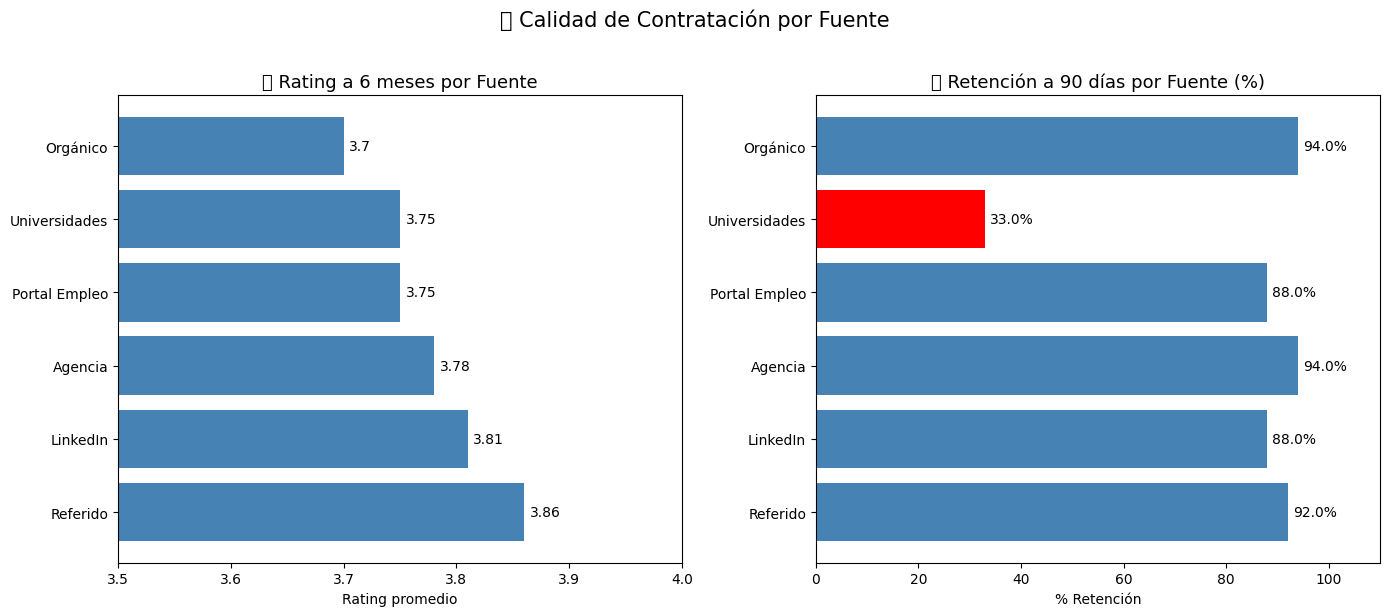

✅ Gráfico guardado en outputs/


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Rating 6 meses
axes[0].barh(calidad.index, calidad['rating_6m'], color='steelblue')
axes[0].set_title('⭐ Rating a 6 meses por Fuente', fontsize=13)
axes[0].set_xlabel('Rating promedio')
axes[0].set_xlim(3.5, 4.0)
for i, v in enumerate(calidad['rating_6m']):
    axes[0].text(v + 0.005, i, str(v), va='center', fontsize=10)

# Retención 90 días
colores = ['red' if x < 70 else 'steelblue' for x in calidad['retencion_90d']]
axes[1].barh(calidad.index, calidad['retencion_90d'], color=colores)
axes[1].set_title('🔄 Retención a 90 días por Fuente (%)', fontsize=13)
axes[1].set_xlabel('% Retención')
axes[1].set_xlim(0, 110)
for i, v in enumerate(calidad['retencion_90d']):
    axes[1].text(v + 1, i, f'{v}%', va='center', fontsize=10)

plt.suptitle('🏆 Calidad de Contratación por Fuente', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/calidad_contratacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en outputs/")

## 📝 Conclusiones

A partir del análisis de 11.637 candidatos identifiqué los siguientes hallazgos clave:

1. **Funnel crítico:** Solo el 0.3% de los candidatos llega a la etapa final del proceso, 
lo que indica filtros muy exigentes o posibles cuellos de botella en etapas intermedias.

2. **Fuente dominante:** LinkedIn concentra el 41% del volumen total de candidatos (4.826), 
seguido por Referidos (2.154) y Portal Empleo (1.846).

3. **Tiempos del proceso:** El Time to Hire promedio es de 16 días, pero el Time to Fill 
llega a 77 días, evidenciando que la posición permanece vacante más de 2 meses en promedio.

4. **Brecha salarial baja:** La diferencia salarial por género es de solo 1.9%, 
lo que refleja un proceso relativamente equitativo en términos de expectativas.

5. **Calidad de contratación:** Los Referidos lideran con 3.86 de rating y 92% de retención 
a 90 días. Universidades presenta la retención más baja (33%), lo que sugiere revisar 
esa fuente de reclutamiento.